In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load Dataset
df = pd.read_csv("/content/diabetes.csv")

# Display the first 5 rows
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
# Basic Dataset Information

print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset:
(768, 9)

Column names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [5]:
# Check Missing Values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
# Create Missing Values for Demonstration

df.loc[2, 'Glucose'] = None
df.loc[2, 'BMI'] = None

print("Missing values after creating them:")
print(df.isnull().sum())

Missing values after creating them:
Pregnancies                 0
Glucose                     1
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         1
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
# Handle Missing Values by Replacing with Mean

imputer = SimpleImputer(strategy='mean')

df['Glucose'] = imputer.fit_transform(df[['Glucose']])
df['BMI'] = imputer.fit_transform(df[['BMI']])

print("Missing values after replacement:")
print(df.isnull().sum())

Missing values after replacement:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
# Features and Target

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Pregnancies     Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0            6  148.000000             72             35        0  33.600000   
1            1   85.000000             66             29        0  26.600000   
2            8  120.813559             64              0        0  32.003911   
3            1   89.000000             66             23       94  28.100000   
4            0  137.000000             40             35      168  43.100000   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target (y):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [9]:
# Split the Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (537, 8)
X_test shape: (231, 8)
y_train shape: (537,)
y_test shape: (231,)


In [10]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train after scaling:")
print(X_train[:5])

X_train after scaling:
[[-0.8362943  -0.80005088 -0.53576428 -0.15714558 -0.18973183 -1.06015343
  -0.61421636 -0.94861028]
 [ 0.39072767 -0.49054341  0.12804365  0.55361931  2.13020339  0.64646721
  -0.90973787 -0.43466673]
 [-1.14304979  0.43797901 -0.09322566  1.39361417  1.47853619  1.35537117
  -0.30699103 -0.77729576]
 [ 0.08397217  0.31417602 -0.09322566  0.03669939  0.74866893  0.14760887
  -0.90681191 -0.43466673]
 [-0.8362943  -0.5524449  -2.19528409  1.13515422  0.02749057  1.48664968
  -0.83951493 -0.00638043]]


In [11]:
# Create KNN Model

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [12]:
# Make Predictions

y_pred = knn.predict(X_test)

print("Predicted outcomes:")
print(y_pred[:20])

Predicted outcomes:
[0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0]


In [13]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.70995670995671
Accuracy Percentage: 70.995670995671 %


In [14]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[124  27]
 [ 40  40]]


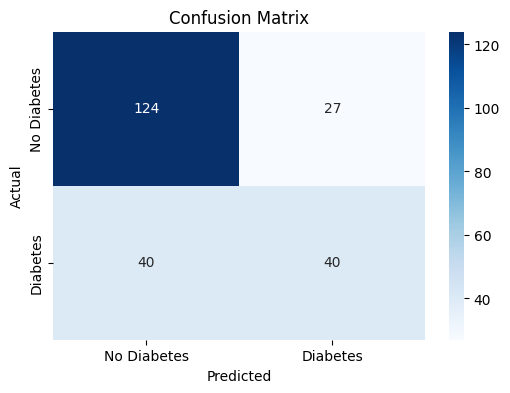

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
# Classification Report

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       151
           1       0.60      0.50      0.54        80

    accuracy                           0.71       231
   macro avg       0.68      0.66      0.67       231
weighted avg       0.70      0.71      0.70       231



In [20]:
import joblib

joblib.dump(knn, "knn_model.pkl")

print("KNN model saved successfully!")

KNN model saved successfully!


In [21]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [22]:
print("Features used by the model:")
print(X.columns.tolist())

print("Number of features:", X.shape[1])

Features used by the model:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Number of features: 8


In [23]:
import os

print("Files in Colab:")
print(os.listdir("/content"))

Files in Colab:
['.config', 'diabetes.csv', 'knn_model.pkl', 'scaler.pkl', 'sample_data']


In [25]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 32.2 MB/s eta 0:00:00


In [69]:
%%writefile app.py

Overwriting app.py


In [41]:
import pickle

with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully using pickle!")

Model and scaler saved successfully using pickle!


In [43]:
import pickle

with open("knn_model.pkl", "rb") as f:
    test_model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    test_scaler = pickle.load(f)

print("Both files loaded successfully!")

Both files loaded successfully!


In [68]:
import streamlit as st
import numpy as np
import pickle

# Load trained model
with open("knn_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load scaler
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Page settings
st.set_page_config(
    page_title="Diabetes Prediction System",
    page_icon="🩺",
    layout="centered"
)

# Title
st.title("🩺 Diabetes Prediction System")
st.write("Enter the patient's medical information below.")

# Model accuracy
st.info("KNN Model Accuracy: 71%")

st.divider()

# Input fields
pregnancies = st.number_input(
    "Pregnancies",
    min_value=0,
    max_value=20,
    value=1
)

glucose = st.number_input(
    "Glucose Level",
    min_value=0.0,
    max_value=300.0,
    value=120.0
)

blood_pressure = st.number_input(
    "Blood Pressure",
    min_value=0.0,
    max_value=150.0,
    value=70.0
)

skin_thickness = st.number_input(
    "Skin Thickness",
    min_value=0.0,
    max_value=100.0,
    value=20.0
)

insulin = st.number_input(
    "Insulin",
    min_value=0.0,
    max_value=900.0,
    value=79.0
)

bmi = st.number_input(
    "BMI",
    min_value=0.0,
    max_value=70.0,
    value=25.0
)

diabetes_pedigree = st.number_input(
    "Diabetes Pedigree Function",
    min_value=0.000,
    max_value=3.000,
    value=0.471,
    format="%.3f"
)

age = st.number_input(
    "Age",
    min_value=1,
    max_value=120,
    value=30
)

st.divider()

# Prediction
if st.button("Predict Diabetes"):

    # Create input array
    sample = np.array([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]])

    # Scale input
    sample_scaled = scaler.transform(sample)

    # Make prediction
    prediction = model.predict(sample_scaled)[0]

    # Get probabilities
    probability = model.predict_proba(sample_scaled)[0]

    # Display probabilities
    st.write(
        f"Estimated probability of No Diabetes: "
        f"**{probability[0] * 100:.1f}%**"
    )

    st.write(
        f"Estimated probability of Diabetes: "
        f"**{probability[1] * 100:.1f}%**"
    )

    # Display result
    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("⚠️ The patient is likely to have Diabetes.")
    else:
        st.success("✅ The patient is unlikely to have Diabetes.")

    st.caption("⚠️ For educational purposes only. Not a substitute for professional medical advice.")

2026-08-26 14:54:44.870 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 14:54:44.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 14:54:44.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 14:54:44.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 14:54:44.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 14:54:44.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 14:54:44.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 14:54:44.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [45]:
import pandas as pd
import numpy as np
import sklearn
import sys

print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Python version: {sys.version.split()[0]}")

pandas version: 2.2.3
numpy version: 2.1.3
scikit-learn version: 1.6.1
Python version: 3.13.15
